### Разминка - вспомним как алгоритм градиентного спуска
Напишите программу (без использования PyTorch) поиска точки минимума функции:

f(x) = 0.5 * x + 0.2 * x** 2 - 0.1 * x**3

c помощью градиентного алгоритма со следующими начальными значениям:
eta = 0.01
x0 = -4
N = 200 - число итерации градиентного алгоритма

In [ ]:
def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.1 * x ** 3


def df(x):
    return # здесь выражение производной функции f(x)


# здесь продолжайте программу

Дана функция f(x) = 0.1 * x**2 - sin(x) + 5
Необходимо выполнить ее аппросксимацию (восстановление) на интервале [-5; 5]
Моделью нейронной сети вида:
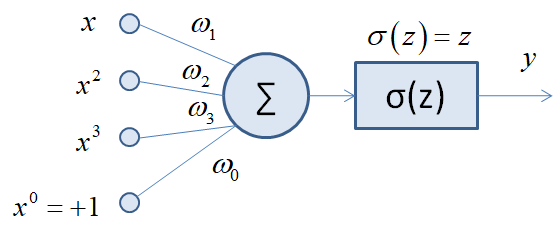

Математически ее работу можно записать следующим образом:
y = a(x) = w0 + w1 * x + w2 * x**2 + w3 * x**3
Вектор ппараметров [w0, w1, w2, w3] следует искать с помощью градиеньного алгоритма, где функционал качества Q представляет собой среднеквадратичную функцию: 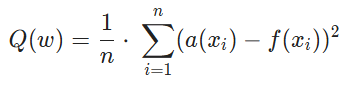

Его частную производную по вектору параметров w можно записать в векторно-матричном виде следующим образом:
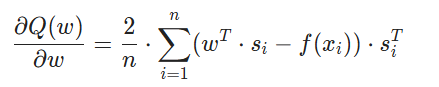
где s = [1, x, x**2, x**3] - вектор признако i-го образа обучающей выборки

Продолжите программу, в которой объявлена функция f(x) с именем func, заданы значения функции по оси абсцисс и ординат, а также начальные значения и параметры для алгоритма градиентного спуска.

Вычисленные параметры вектора w следует сохранить в виде тензора с именем w. Также нужно вычислить значение среднего эмпирического риска для обученной модели по формуле:
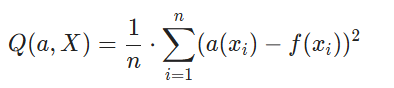

In [ ]:
import torch

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return 0.1 * x**2 - torch.sin(x) + 5.


# здесь объявляйте необходимые функции


coord_x = torch.arange(-5.0, 5.0, 0.1) # значения по оси абсцисс [-5; 5] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

sz = coord_x.size(0)	# количество значений функций (точек)
eta = torch.tensor([0.1, 0.01, 0.001, 0.0001]) # шаг обучения для каждого параметра w0, w1, w2, w3
w = torch.zeros(4, dtype=torch.float32) # начальные значения параметров модели
N = 200 # число итераций градиентного алгоритма

# здесь продолжайте программу

**Закрепим материал по автоматическому дифференцированию:**

Расстояние, пройденное телом за время t описывается выражением:
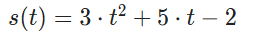

Мгновенную скорость этого тела в момент времени t=d можно найти, как производную пути по времени:
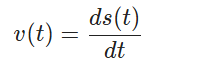

В программе ниже выполняется чтение момента времени d, при котором необходимо вычислить скорость тела:

d = float(input())

Сформируйте тензор t со значением d и с помощью автоматического дифференцирования фреймворка PyTorch найдите мгновенную скорость тела в момент t=d. Результат вычисления производной ds(t)/dt следует хранить в тензоре t.

In [ ]:
import torch

tests = [4.5, -2.3, 0.1, 40.0]

for d in tests:
    t =

In [ ]:
Следующее задание:

В программе дана следующая функция:

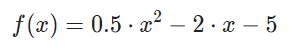

которую предполагается аппроксимировать (восстанавливать) с помощью следующей модели нейронной сети:

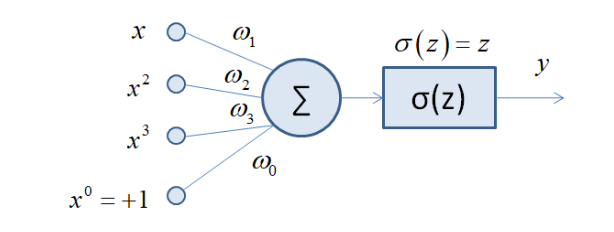

Математические ее работу можно описать следующим выражением:

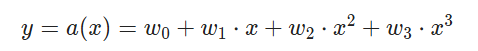

Критерием качества будет выступать квадратичная функция потерь вида:

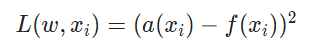

Найдите значения производных ∂L/∂w0, ∂L/∂w1, ∂L/∂w2, ∂L/∂w3 в точке:

xx = float(input())
x = torch.tensor(xx, dtype=torch.float32)

In [ ]:
import torch

tests = [
    (2.5,  (0.12, 0.5, -2.3, 0.1)),
    (-0.5, (5.12, -1.5, 1.3, -0.5)),
    (3.0,  (-4.3, 0.1, 0.2, -0.01)),
]

for xx, (x0, x1, x2, x3) in tests:
    x = torch.tensor(xx, dtype=torch.float32)

    w0 = torch.tensor(x0, dtype=torch.float32, requires_grad=True)
    w1 = torch.tensor(x1, dtype=torch.float32, requires_grad=True)
    w2 = torch.tensor(x2, dtype=torch.float32, requires_grad=True)
    w3 = torch.tensor(x3, dtype=torch.float32, requires_grad=True)

    # здесь решение

**Обучение полносвязной нейронной сети на MNIST**

**Dataset и transforms**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

`device` - где лежат тензоры и где считаются операции: видеокарта (`cuda`) или процессор (`cpu`). Строка выбирает видеокарту, если она доступна, иначе процессор. Дальше и модель, и данные нужно переносить на один и тот же `device` - иначе PyTorch выдаст ошибку несовпадения устройств.

## Данные

`datasets.MNIST` - готовый `Dataset` из `torchvision`: объект, у которого можно спросить длину (`len(dataset)`) и взять пример по индексу (`dataset[i]`), в ответ он отдает пару (картинка, метка). `transform=transforms.ToTensor()` переводит картинку из обычного изображения в тензор формы `(1, 28, 28)` со значениями от 0 до 1 - без этого преобразования датасет отдавал бы не тензор, а объект-картинку, с которым PyTorch не умеет работать напрямую.

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(len(train_dataset), len(test_dataset))

image, label = train_dataset[0]
print(image.shape, label)

`train=True` / `train=False` - MNIST заранее разбит на две части: обучающую и тестовую. Модель обучается только на первой и ни разу не видит вторую до самой проверки.

`Dataset` отдает примеры по одному. Чтобы собирать их в пачки и перемешивать порядок каждую эпоху, используется `DataLoader`.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

`batch_size` - сколько примеров в одной пачке. `shuffle=True` перемешивает порядок каждую эпоху - нужно для обучающей выборки, бессмысленно для тестовой, поэтому там `shuffle=False`. Форма пачки `(64, 1, 28, 28)` — спереди добавилось измерение пачки.

## Слои сети - по одному

Модель в PyTorch - класс, унаследованный от `nn.Module`, с двумя методами: `__init__`, где перечисляются слои, и `forward`, где описано, в каком порядке через них проходят данные. Когда пишут `model(x)`, PyTorch сам вызывает `model.forward(x)`.

Разберем по отдельности три слоя, из которых можно собрать простую сеть. Пример ниже - игрушечный, не для MNIST, просто чтобы увидеть синтаксис класса в действии.

In [ ]:
class ExampleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(10, 3)  # 10 входных чисел -> 3 выходных

    def forward(self, x):
        return self.layer(x)


example_net = ExampleNet()
dummy_input = torch.rand(4, 10)  # пачка из 4 примеров по 10 чисел
print(example_net(dummy_input).shape)

`super().__init__()` - обязательная первая строка `__init__`: она настраивает внутренний учет параметров у `nn.Module`, без нее слои не зарегистрируются как обучаемые и оптимизатор их не увидит.

`nn.Linear(in_features, out_features)` - полносвязный слой: линейное преобразование `x @ W + b`, где `W` и `b` создаются автоматически при создании слоя и являются обучаемыми параметрами. На входе ждет тензор формы `(батч, in_features)`, на выходе отдает `(батч, out_features)` — в примере выше `(4, 10)` превратилось в `(4, 3)`.

MNIST-картинка после `ToTensor()` имеет форму `(1, 28, 28)` - это не плоский вектор, а `nn.Linear` умеет работать только с плоскими векторами. Превращает одно в другое `nn.Flatten()`.

In [ ]:
flatten = nn.Flatten()
dummy_images = torch.rand(4, 1, 28, 28)  # как будто пачка из 4 картинок MNIST
print(flatten(dummy_images).shape)

`(4, 1, 28, 28)` превратилось в `(4, 784)` — все измерения, кроме первого (пачки), схлопнулись в одно. `28 * 28 = 784`.

Последний блок - нелинейность между слоями. Без нее несколько `nn.Linear` подряд математически эквивалентны одному линейному слою, сколько бы их ни было.

In [ ]:
relu = nn.ReLU()
print(relu(torch.tensor([-2.0, -0.5, 0.0, 1.5, 3.0])))

`nn.ReLU()` - поэлементно `max(0, x)`: отрицательные значения обнуляются, остальные проходят без изменений.

Три этих блока - `nn.Flatten`, `nn.Linear`, `nn.ReLU` - и есть весь набор, нужный для того, чтобы собрать сеть под MNIST. Как именно их комбинировать (сколько слоев, какой ширины) - решать в задании ниже.

## Функция потерь и оптимизатор

`nn.CrossEntropyLoss()` - функция потерь для классификации на несколько классов. Ждет на входе сырые логиты (то, что отдает последний `nn.Linear`, без какой-либо активации после него) и целые числа-метки классов, а softmax считает сама, внутри себя. Если применить softmax к выходу модели самостоятельно и передать результат в `CrossEntropyLoss`, softmax применится дважды и обучение будет некорректным - поэтому последний слой сети всегда оставляют без активации.

In [ ]:
loss_fn = nn.CrossEntropyLoss()

dummy_logits = torch.randn(4, 3)         # как будто выход ExampleNet на 4 примерах, 3 класса
dummy_labels = torch.tensor([0, 2, 1, 0])  # правильные классы для них

print(loss_fn(dummy_logits, dummy_labels))

## Что делает backward и как обновлять веса вручную

После `loss.backward()` у каждого параметра модели (все, что отдает `model.parameters()`) появляется заполненное поле `.grad` — градиент loss по этому параметру. Сам `backward()` веса не меняет, он только считает, в какую сторону и насколько сильно каждый вес влияет на ошибку. Дальше нужно сделать шаг градиентного спуска самим: каждый параметр сдвинуть против своего градиента на небольшую величину.

Покажем на `example_net`.

In [ ]:
output = example_net(dummy_input)
target = torch.tensor([0, 2, 1, 0])  # произвольные "правильные" классы, для примера

loss = loss_fn(output, target)
loss.backward()

print(example_net.layer.weight.grad.shape)

`example_net.layer.weight.grad` - градиент loss по весам слоя `layer`, той же формы, что и сами веса. Теперь шаг обновления:

In [ ]:
lr = 0.01

with torch.no_grad():
    for param in example_net.parameters():
        param -= lr * param.grad
        param.grad.zero_()

`torch.no_grad()` — сам шаг обновления не должен попадать в граф вычислений (иначе PyTorch попытается продифференцировать и это изменение весов, что не нужно). `param -= lr * param.grad` — сдвиг параметра против градиента, `lr` задает величину шага: слишком большой — модель будет "перепрыгивать" через нужные значения весов, слишком маленький — обучение будет идти очень медленно. `param.grad.zero_()` обнуляет градиент после того, как он использован — PyTorch по умолчанию не обнуляет градиенты сам, а прибавляет новые к уже накопленным, поэтому без обнуления на следующем шаге градиенты просто сложатся со старыми.

## Цикл обучения и проверки

Функции ниже не привязаны к конкретной архитектуре — они принимают модель как аргумент и одинаково работают с любой сетью, собранной из `nn.Module`. Их можно оставить как есть и переиспользовать для своей модели в задании.

In [ ]:
def train_one_epoch(model, loader, loss_fn, lr, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        #  нужно найти функцию потерь (назовите ее loss) и подсчитать обратное распространение

        with torch.no_grad():
            for param in model.parameters():
                # написать шаг обучения

        running_loss += loss.item()
    return running_loss / len(loader)

По шагам внутри цикла:

- `model.train()` - переключает модель в режим обучения.
- `images, labels = images.to(device), labels.to(device)` - переносит пачку на то же устройство, где лежит модель.
- `outputs = model(images)` - прямой проход через сеть.
- `loss = loss_fn(outputs, labels)` - насколько предсказания разошлись с правильными метками.
- `loss.backward()` - считает градиент loss по всем обучаемым параметрам модели.
- дальше - тот же самый ручной шаг обновления, что и в примере с `example_net` выше, только сразу для всех параметров модели циклом.

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

`model.eval()` - режим использования модели, противоположность `model.train()`. `torch.no_grad()` отключает подсчет градиентов внутри блока — на проверке они не нужны. `outputs.argmax(dim=1)` берет индекс наибольшего логита по каждому примеру - это и есть предсказанный класс. `(preds == labels).sum().item()` считает число верных предсказаний в пачке.

---

## Задание

Используя три блока выше (`nn.Flatten`, `nn.Linear`, `nn.ReLU`) и функции `train_one_epoch`, `evaluate`, соберите свою сеть и обучите ее распознавать цифры MNIST.  Архитектуру, число слоев и их ширину нужно придумать и написать самим.

Работайте по группам. Правила, чтобы результаты были сравнимы:

- модель обучается с нуля, без предобученных весов;
- тестовая часть (`test_dataset`, `test_loader`) не используется во время обучения ни в каком виде, только для финальной проверки;
- итоговый результат - это `evaluate(model, test_loader, device)`, ровно той же функцией, что определена выше.

Что можно менять и пробовать: сколько слоев `nn.Linear` использовать и какой ширины, другую активацию вместо `nn.ReLU` (например `nn.LeakyReLU`), оптимизатор и `lr` (`torch.optim.SGD` вместо `Adam`, другие значения скорости обучения), число эпох, размер батча. Можно добавить `nn.Dropout(p)` между линейными слоями - во время обучения он случайно обнуляет долю `p` нейронов на каждом шаге, из-за чего сети сложнее подстроиться под конкретные примеры из обучающей выборки.

In [ ]:
class MyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # опишите свои слои здесь

    def forward(self, x):
        # опишите свой прямой проход здесь
        return x

In [ ]:
my_model = MyClassifier().to(device)
my_loss_fn = nn.CrossEntropyLoss()
my_lr =   # подберите сами

my_epochs =   # подберите сами

for epoch in range(my_epochs):
    train_loss = train_one_epoch(my_model, train_loader, my_loss_fn, my_lr, device)
    test_acc = evaluate(my_model, test_loader, device)
    print(f"Эпоха {epoch + 1}/{my_epochs}: loss = {train_loss:.4f}, точность на тесте = {test_acc:.4f}")

In [ ]:
# итоговый результат группы - его и сравниваем между группами
final_accuracy = evaluate(my_model, test_loader, device)
print(f"Итоговая точность на тесте: {final_accuracy:.4f}")